In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

In [25]:
class Dataset:

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None

    def load(self):

        self.df = pd.read_csv(self.filepath)

        print("Shape :", self.df.shape)

        return self.df

    def head(self, n=5):

        return self.df.head(n)

    def info(self):

        return self.df.info()

    def missing_values(self):

        return self.df.isnull().sum()

    def churn_distribution(self):

        return (
            self.df["Exited"]
            .value_counts(normalize=True)
            * 100
        )

In [26]:
class Preprocessor:

    def __init__(self, df):

        self.df = df.copy()

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None

        self.y_train = None
        self.y_test = None

        self.scaler = None

        self.X_train_scaled = None
        self.X_test_scaled = None

    def clean_data(self):

        self.df = self.df.drop(
            columns=[
                "RowNumber",
                "CustomerId",
                "Surname"
            ]
        )

        self.df = pd.get_dummies(
            self.df,
            columns=[
                "Geography",
                "Gender"
            ],
            drop_first=True
        )

        for col in self.df.columns:

            if self.df[col].dtype == bool:

                self.df[col] = (
                    self.df[col]
                    .astype(int)
                )

        return self.df

    def split(self):

        self.X = self.df.drop(
            "Exited",
            axis=1
        )

        self.y = self.df["Exited"]

        (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        ) = train_test_split(
            self.X,
            self.y,
            test_size=0.20,
            random_state=42,
            stratify=self.y
        )

        return (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test
        )

    def scale(self):

        self.scaler = StandardScaler()

        self.X_train_scaled = (
            self.scaler.fit_transform(
                self.X_train
            )
        )

        self.X_test_scaled = (
            self.scaler.transform(
                self.X_test
            )
        )

        return (
            self.X_train_scaled,
            self.X_test_scaled
        )

In [27]:
class LogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(
        self,
        X_train,
        y_train
    ):

        self.model.fit(
            X_train,
            y_train
        )

        return self

    def predict(
        self,
        X_test
    ):

        self.y_pred = (
            self.model.predict(X_test)
        )

        self.y_prob = (
            self.model.predict_proba(X_test)
            [:,1]
        )

        self.z_score = (
            self.model.decision_function(
                X_test
            )
        )

        return (
            self.y_pred,
            self.y_prob,
            self.z_score
        )

    def coefficients(
        self,
        feature_names
    ):

        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient":
            self.model.coef_[0]
        })

        return coef_df.sort_values(
            by="Coefficient",
            ascending=False
        )

    def odds_ratio(
        self,
        feature_names
    ):

        odds_df = pd.DataFrame({
            "Feature": feature_names,
            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            )
        })

        return odds_df.sort_values(
            by="Odds Ratio",
            ascending=False
        )

    def intercept(self):

        return self.model.intercept_[0]

In [28]:
class Evaluation:

    @staticmethod
    def metrics(
        y_true,
        y_pred,
        y_prob
    ):

        return pd.DataFrame({

            "Metric":[
                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score",
                "ROC AUC"
            ],

            "Value":[
                accuracy_score(
                    y_true,
                    y_pred
                ),

                precision_score(
                    y_true,
                    y_pred
                ),

                recall_score(
                    y_true,
                    y_pred
                ),

                f1_score(
                    y_true,
                    y_pred
                ),

                roc_auc_score(
                    y_true,
                    y_prob
                )
            ]
        })

    @staticmethod
    def report(
        y_true,
        y_pred
    ):

        return classification_report(
            y_true,
            y_pred
        )

    @staticmethod
    def confusion(
        y_true,
        y_pred
    ):

        return confusion_matrix(
            y_true,
            y_pred
        )

In [29]:
class Visualization:

    @staticmethod
    def show_all(
        df,
        z_score,
        y_prob,
        y_test,
        cm,
        coef_df
    ):

        # Churn Distribution
        plt.figure(figsize=(6,4))
        sns.countplot(x=df["Exited"])
        plt.title("Distribusi Customer Churn")
        plt.show()

        # Sigmoid
        z = np.linspace(-10,10,1000)
        sigmoid = 1/(1+np.exp(-z))

        plt.figure(figsize=(8,5))
        plt.plot(z,sigmoid)
        plt.title("Sigmoid Function")
        plt.show()

        # Sigmoid Transformation
        plt.figure(figsize=(8,5))
        plt.scatter(
            z_score,
            y_prob,
            alpha=0.4
        )
        plt.title(
            "Sigmoid Transformation"
        )
        plt.show()

        # Confusion Matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
        plt.show()

        # Precision Recall Curve
        precision_curve, recall_curve, _ = (
            precision_recall_curve(
                y_test,
                y_prob
            )
        )

        plt.figure(figsize=(8,5))
        plt.plot(
            recall_curve,
            precision_curve
        )
        plt.show()

        # Coefficient Plot
        plt.figure(figsize=(10,6))
        sns.barplot(
            data=coef_df,
            x="Coefficient",
            y="Feature"
        )
        plt.show()

In [30]:
if __name__ == "__main__":

    data = Dataset(
        "Churn_Modelling.csv"
    )

    df = data.load()

    prep = Preprocessor(df)

    prep.clean_data()

    prep.split()

    prep.scale()

    model = LogisticRegressionModel()

    model.fit(
        prep.X_train_scaled,
        prep.y_train
    )

    (
        y_pred,
        y_prob,
        z_score
    ) = model.predict(
        prep.X_test_scaled
    )

    metrics_df = Evaluation.metrics(
        prep.y_test,
        y_pred,
        y_prob
    )

    report = Evaluation.report(
        prep.y_test,
        y_pred
    )

    cm = Evaluation.confusion(
        prep.y_test,
        y_pred
    )

    coef_df = model.coefficients(
        prep.X.columns
    )

    odds_df = model.odds_ratio(
        prep.X.columns
    )

    print(metrics_df)

    print(report)

    display(coef_df)

    display(odds_df)

Shape : (10000, 14)
      Metric     Value
0   Accuracy  0.808000
1  Precision  0.589147
2     Recall  0.186732
3   F1 Score  0.283582
4    ROC AUC  0.774778
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



,Feature,Coefficient
1,Age,0.738847
8,Geography_Germany,0.356679
3,Balance,0.160622
7,EstimatedSalary,0.047725
9,Geography_Spain,0.018907
2,Tenure,-0.020071
5,HasCrCard,-0.032208
4,NumOfProducts,-0.070292
0,CreditScore,-0.085986
10,Gender_Male,-0.260851


,Feature,Odds Ratio
1,Age,2.093520
8,Geography_Germany,1.428578
3,Balance,1.174241
7,EstimatedSalary,1.048882
9,Geography_Spain,1.019087
2,Tenure,0.980129
5,HasCrCard,0.968306
4,NumOfProducts,0.932122
0,CreditScore,0.917607
10,Gender_Male,0.770396


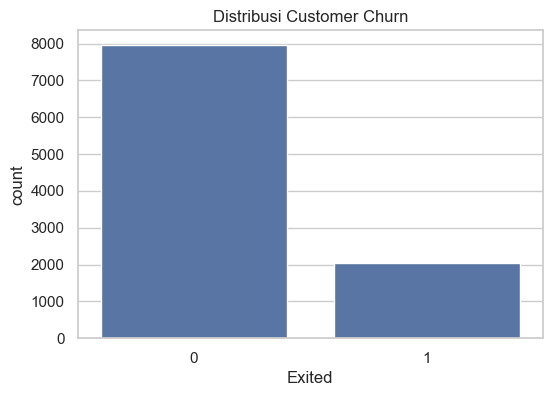

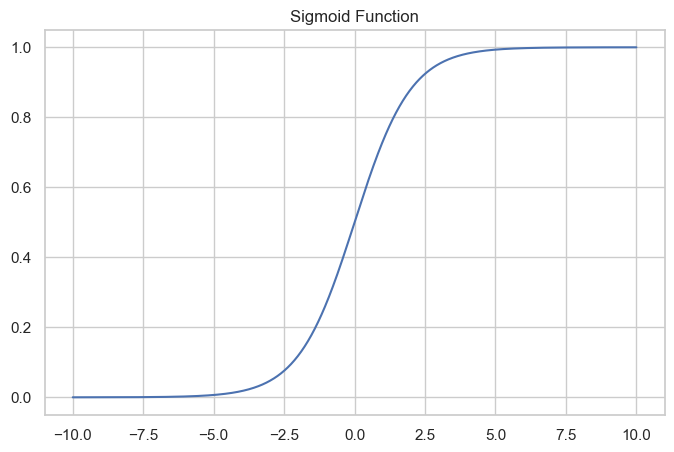

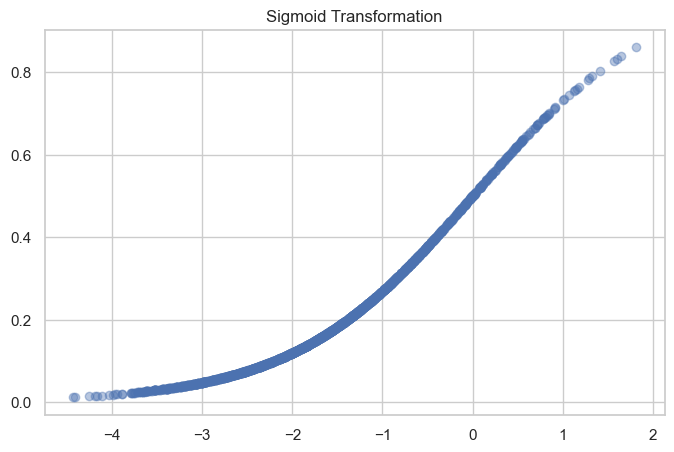

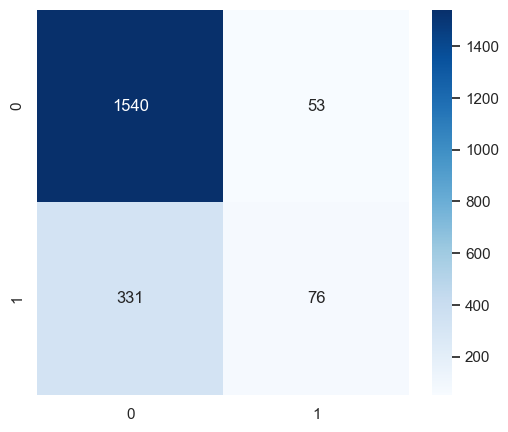

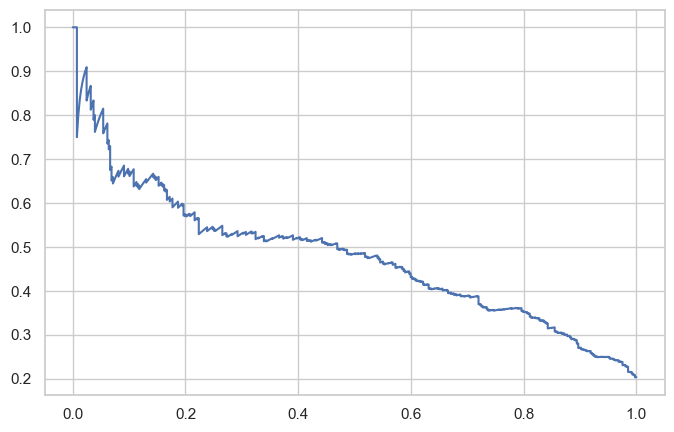

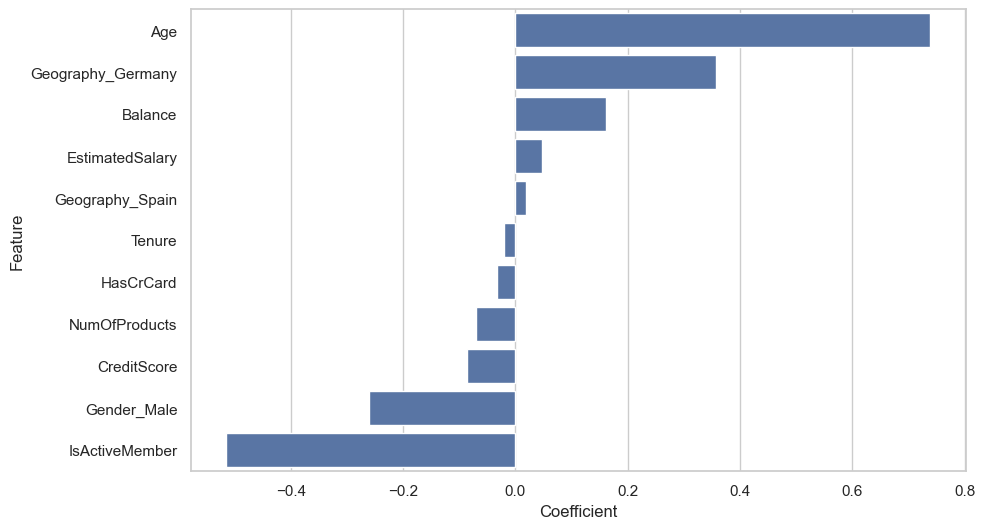

In [31]:
if __name__ == "__main__":

    Visualization.show_all(
        df,
        z_score,
        y_prob,
        prep.y_test,
        cm,
        coef_df
    )